#Pip install (run once and delete)

In [ ]:
!pip install pdf2image pillow
!apt-get install -y poppler-utils
!pip install beautifulsoup4
!pip install pythainlp

#Mount GG drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


#Insert path

In [84]:
district="อำเภอฮอด"
tumbol="ตำบลหางดง"
nuay="หน่วยที่ 5"
number="5"

to run this, don't forget to create a short cut for จังหวัดเชียงใหม่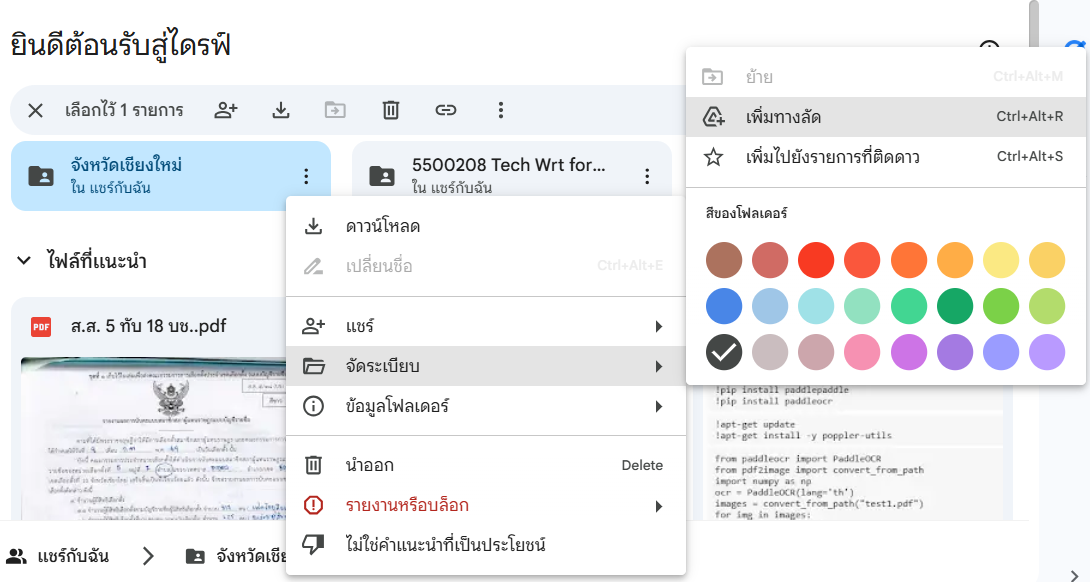

In [15]:
import os

folder_path = "/content/drive/MyDrive/จังหวัดเชียงใหม่/เขตเลือกตั้งที่ 10/"+district+"/"+tumbol+"/"+nuay

# List files
for f in os.listdir(folder_path):
    print(f)

ส.ส. 5 ทับ 18.pdf
ส.ส. 5 ทับ 18 บช..pdf


In [16]:
pdf_files = [f for f in os.listdir(folder_path) if f.endswith(".pdf")]
print(pdf_files)

['ส.ส. 5 ทับ 18.pdf', 'ส.ส. 5 ทับ 18 บช..pdf']


Recheck this respect to file ordering, some folder file ordering is in different pattern

In [29]:
party_path = os.path.join(folder_path, pdf_files[1])
roster_path = os.path.join(folder_path, pdf_files[0])

#Data Template

In [34]:
parties = {
    1: [1, "พรรคไทยทรัพย์ทวี", 0, ""],
    2: [2, "พรรคเพื่อชาติไทย", 0, ""],
    3: [3, "พรรคใหม่", 0, ""],
    4: [4, "พรรคมิติใหม่", 0, ""],
    5: [5, "พรรครวมใจไทย", 0, ""],
    6: [6, "พรรครวมไทยสร้างชาติ", 0, ""],
    7: [7, "พรรคพลวัต", 0, ""],
    8: [8, "พรรคประชาธิปไตยใหม่", 0, ""],
    9: [9, "พรรคเพื่อไทย", 0, ""],
    10: [10, "พรรคทางเลือกใหม่", 0, ""],
    11: [11, "พรรคเศรษฐกิจ", 0, ""],
    12: [12, "พรรคเสรีรวมไทย", 0, ""],
    13: [13, "พรรครวมพลังประชาชน", 0, ""],
    14: [14, "พรรคท้องที่ไทย", 0, ""],
    15: [15, "พรรคอนาคตไทย", 0, ""],
    16: [16, "พรรคพลังเพื่อไทย", 0, ""],
    17: [17, "พรรคไทยชนะ", 0, ""],
    18: [18, "พรรคพลังสังคมใหม่", 0, ""],
    19: [19, "พรรคสังคมประชาธิปไตย", 0, ""],
    20: [20, "พรรคฟิวชัน", 0, ""],
    21: [21, "พรรคไทรวมพลัง", 0, ""],
    22: [22, "พรรคก้าวอิสระ", 0, ""],
    23: [23, "พรรคปวงชนไทย", 0, ""],
    24: [24, "พรรควิชชั่นใหม่", 0, ""],
    25: [25, "พรรคเพื่อชีวิตใหม่", 0, ""],
    26: [26, "พรรคคลองไทย", 0, ""],
    27: [27, "พรรคประชาธิปัตย์", 0, ""],
    28: [28, "พรรคไทยก้าวหน้า", 0, ""],
    29: [29, "พรรคไทยภักดี", 0, ""],
    30: [30, "พรรคแรงงานสร้างชาติ", 0, ""],
    31: [31, "พรรคประชากรไทย", 0, ""],
    32: [32, "พรรคครูไทยเพื่อประชาชน", 0, ""],
    33: [33, "พรรคประชาชาติ", 0, ""],
    34: [34, "พรรคสร้างอนาคตไทย", 0, ""],
    35: [35, "พรรครักชาติ", 0, ""],
    36: [36, "พรรคไทยพร้อม", 0, ""],
    37: [37, "พรรคภูมิใจไทย", 0, ""],
    38: [38, "พรรคพลังธรรมใหม่", 0, ""],
    39: [39, "พรรคกรีน", 0, ""],
    40: [40, "พรรคไทยธรรม", 0, ""],
    41: [41, "พรรคแผ่นดินธรรม", 0, ""],
    42: [42, "พรรคกล้าธรรม", 0, ""],
    43: [43, "พรรคพลังประชารัฐ", 0, ""],
    44: [44, "พรรคโอกาสใหม่", 0, ""],
    45: [45, "พรรคเป็นธรรม", 0, ""],
    46: [46, "พรรคประชาชน", 0, ""],
    47: [47, "พรรคประชาไทย", 0, ""],
    48: [48, "พรรคไทยสร้างไทย", 0, ""],
    49: [49, "พรรคไทยก้าวใหม่", 0, ""],
    50: [50, "พรรคประชาอาสาชาติ", 0, ""],
    51: [51, "พรรคพร้อม", 0, ""],
    52: [52, "พรรคเครือข่ายชาวนาแห่งประเทศไทย", 0, ""],
    53: [53, "พรรคไทยพิทักษ์ธรรม", 0, ""],
    54: [54, "พรรคความหวังใหม่", 0, ""],
    55: [55, "พรรคไทยรวมไทย", 0, ""],
    56: [56, "พรรคเพื่อบ้านเมือง", 0, ""],
    57: [57, "พรรคพลังไทยรักชาติ", 0, ""]
}

In [35]:
check = {
    1: [1, "จำนวนผู้มีสิทธิเลือกตั้งตามบัญชีรายชื่อผู้มีสิทธิเลือกตั้ง", 0, ""],
    2: [2, "จำนวนผู้มีสิทธิเลือกตั้งที่มาแสดงตน", 0, ""],
    3: [3, "บัตรเลือกตั้งที่ได้รับจัดสรร", 0, ""],
    4: [4, "บัตรเลือกตั้งที่ใช้", 0, ""],
    5: [5, "บัตรดี", 0, ""],
    6: [6, "บัตรเสีย", 0, ""],
    7: [7, "บัตรที่ไม่เลือกบัญชีรายชื่อของพรรคการเมืองใด", 0, ""],
    8: [7, "บัตรเลือกตั้งที่เหลือ", 0, ""]
}

In [36]:
check2 = {
    1: [1, "จำนวนผู้มีสิทธิเลือกตั้งตามบัญชีรายชื่อผู้มีสิทธิเลือกตั้ง", 0, ""],
    2: [2, "จำนวนผู้มีสิทธิเลือกตั้งที่มาแสดงตน", 0, ""],
    3: [3, "บัตรเลือกตั้งที่ได้รับจัดสรร", 0, ""],
    4: [4, "บัตรเลือกตั้งที่ใช้", 0, ""],
    5: [5, "บัตรดี", 0, ""],
    6: [6, "บัตรเสีย", 0, ""],
    7: [7, "บัตรที่ไม่เลือกบัญชีรายชื่อของพรรคการเมืองใด", 0, ""],
    8: [7, "บัตรเลือกตั้งที่เหลือ", 0, ""]
}

In [37]:
roster = {
    1: [1, "นางสาวศรีโสภา โกฏคำลือ", "พรรคเพื่อไทย",0, ""],
    2: [2, "นายสุนทร มาลีการุณกิจ", "พรรคภูมิใจไทย",0, ""],
    3: [3, "นายชาตรี หล้าพระบาง", "พรรคประชาธิปัตย์", 0, ""],
    4: [4, "นายนรพล ตันติมนตรี","พรรคกล้าธรรม", 0, ""],
    5: [5, "นายธวัชชัย แสงสว่าง","พรรคพลังประชารัฐ", 0, ""],
    6: [6, "นายอิทธิธัญกร ตาดำ","พรรคประชาชน", 0, ""],
}

#Preprocess party

In [30]:
import cv2
from PIL import Image

def preprocess(img,pages):
    arr = np.array(img)
    # 1. Crop
    if (pages == 0):
        cropped_arr = arr[400:,]
    else:
        cropped_arr = arr[300:,]

    # 2. Grayscale
    gray = cv2.cvtColor(cropped_arr, cv2.COLOR_BGR2GRAY)

    # 3. Denoise (optional but helps OCR)
    denoised = cv2.GaussianBlur(gray, (3, 3), 0)

    # 4. Adaptive Threshold
    thresh = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21,
        10
    )

    return thresh

In [31]:
from pdf2image import convert_from_path
import numpy as np
images = convert_from_path(party_path)
for i, img in enumerate(images):
    if i < 3:
      fine_img=preprocess(img,i)
      cv2.imwrite(f"page_{i+1}_processed.jpg", fine_img)

#Typhoon OCR

In [32]:
import requests
import json

def extract_text_from_image(image_path, api_key, model, task_type, max_tokens, temperature, top_p, repetition_penalty, pages=None):
    url = "https://api.opentyphoon.ai/v1/ocr"

    with open(image_path, 'rb') as file:
        files = {'file': file}
        data = {
            'model': model,
            'task_type': task_type,
            'max_tokens': str(max_tokens),
            'temperature': str(temperature),
            'top_p': str(top_p),
            'repetition_penalty': str(repetition_penalty)
        }

        if pages:
            data['pages'] = json.dumps(pages)

        headers = {
            'Authorization': f'Bearer {api_key}'
        }

        response = requests.post(url, files=files, data=data, headers=headers)

        if response.status_code == 200:
            result = response.json()

            # Extract text from successful results
            extracted_texts = []
            for page_result in result.get('results', []):
                if page_result.get('success') and page_result.get('message'):
                    content = page_result['message']['choices'][0]['message']['content']
                    try:
                        # Try to parse as JSON if it's structured output
                        parsed_content = json.loads(content)
                        text = parsed_content.get('natural_text', content)
                    except json.JSONDecodeError:
                        text = content
                    extracted_texts.append(text)
                elif not page_result.get('success'):
                    print(f"Error processing {page_result.get('filename', 'unknown')}: {page_result.get('error', 'Unknown error')}")

            return '\n'.join(extracted_texts)
        else:
            print(f"Error: {response.status_code}")
            print(response.text)
            return None

#Function to read output from OCR for party

In [65]:
from bs4 import BeautifulSoup
import re

THAI_NUM_MAP = str.maketrans("๐๑๒๓๔๕๖๗๘๙", "0123456789")

def parse_ocr_to_parties(html_output, parties):
    soup = BeautifulSoup(html_output, "html.parser")
    rows = soup.find_all("tr")

    for row in rows:
        # Skip header rows containing <th>
        if row.find("th"):
            continue

        cols = row.find_all("td")
        if len(cols) < 3:
            continue

        # Party number
        raw_num = cols[0].get_text(strip=True).replace(".", "").translate(THAI_NUM_MAP)
        try:
            party_num = int(raw_num)
        except ValueError:
            continue

        # Score column — detect ANY colspan (2, 3, etc.) or separate cells
        score_col = cols[2]
        colspan   = score_col.get("colspan")
        is_merged = colspan is not None and int(colspan) >= 2

        if is_merged:
            full_text = score_col.get_text(strip=True).translate(THAI_NUM_MAP)
            # Strip leading non-numeric chars e.g. "T8150" → "8150"
            full_text = re.sub(r"^[^\d]*", "", full_text)
            match = re.match(r"(\d+)\s*\(([^)]+)\)", full_text)
            if match:
                score_text = match.group(1)
                score_word = match.group(2)
            else:
                score_text = full_text
                score_word = ""
        else:
            if len(cols) < 4:
                continue
            score_text = cols[2].get_text(strip=True).translate(THAI_NUM_MAP)
            score_word = cols[3].get_text(strip=True).strip("()")

        try:
            score = int(score_text)
        except ValueError:
            score = score_text  # let clean_value handle it

        if party_num in parties:
            parties[party_num][2] = score
            parties[party_num][3] = score_word.strip()

    return parties

In [66]:
def parse_page1(ocr_output, check, parties):
    # Find FIRST table — everything before is text, everything after is html
    table_match = re.search(r"<table[\s>]", ocr_output, re.IGNORECASE)
    if table_match:
        text_part = ocr_output[:table_match.start()]
        html_part = ocr_output[table_match.start():]
    else:
        print("⚠️  No <table> found in page 1 output")
        text_part = ocr_output
        html_part = ""

    # --- Parse text part into check ---
    pattern = r'จำนวน\s+([\d,]+)\s+(?:คน|บัตร)\s*\(([^)]+)\)'
    matches = re.findall(pattern, text_part)

    if not matches:
        print("⚠️  No check values found in text part")
    else:
        for i, (num, word) in enumerate(matches, start=1):
            if i in check:
                check[i][2] = int(num.replace(",", ""))
                check[i][3] = word
                print(f"  check[{i}] = {num} ({word})")

    # --- Parse HTML table part into parties ---
    if html_part:
        parties = parse_ocr_to_parties(html_part, parties)

    return check, parties


def parse_page_other(ocr_output, parties):
    return parse_ocr_to_parties(ocr_output, parties)

#OCR for party

In [67]:
api_key = "sk-tAWWmsJV8aUu31PNMOknMALwpy6tX764grjUpcSkFALIXYNe"
for i in range (1,4):
  image_path = "page_"+str(i)+"_processed.jpg"  # or path/to/your/document.pdf
  model = "typhoon-ocr"
  task_type = "default"
  max_tokens = 16384
  temperature = 0.1
  top_p = 0.6
  repetition_penalty = 1.2
  pages = None
  extracted_text = extract_text_from_image(image_path, api_key, model, task_type, max_tokens, temperature, top_p, repetition_penalty, pages)

  if i == 1:
    print(extracted_text)
    check, parties = parse_page1(extracted_text, check, parties)

  else:
    onlyhtml_text = re.sub(r'^.*?(?=<)', '', extracted_text)
    print(onlyhtml_text)
    parties = parse_page_other(onlyhtml_text, parties)


ตามที่ได้มีพระราชกฤษฎีกาให้มีการเลือกตั้งสมาชิกสภาผู้แทนราษฎร และคณะกรรมการการเลือกตั้ง ได้กำหนดให้วันที่ 5 เดือน ก.พ. พ.ศ. 69 เป็นวันเลือกตั้ง นั้น

บัดนี้ คณะกรรมการประจำหน่วยเลือกตั้งได้ดำเนินการนับคะแนนสมาชิกสภาผู้แทนราษฎรแบบบัญชีรายชื่อของหน่วยเลือกตั้งที่ 5 หมู่ที่ 7 (ตำบล/แขวง/เทศบาล บางคล้า) อำเภอ/เขต สอด เขตเลือกตั้งที่ 10 จังหวัดเชียงใหม่ เสร็จสิ้นเป็นที่เรียบร้อยแล้ว ดังนั้น จึงขอรายงานผลการนับคะแนนของหน่วยเลือกตั้งดังกล่าว ดังนี้

๑. จำนวนผู้มีสิทธิเลือกตั้ง
    ๑.๑ จำนวนผู้มีสิทธิเลือกตั้งตามบัญชีรายชื่อผู้มีสิทธิเลือกตั้ง จำนวน 817 คน (แปดร้อยสิบเจ็ดคน)
    ๑.๒ จำนวนผู้มีสิทธิเลือกตั้งที่มาแสดงตน (เฉพาะวันเลือกตั้ง) จำนวน 625 คน (หกร้อยยี่สิบห้า)

๒. จำนวนบัตรเลือกตั้ง
    ๒.๑ จำนวนบัตรเลือกตั้งที่ได้รับจัดสรร จำนวน 800 บัตร (แปดร้อยบัตร)
    ๒.๒ จำนวนบัตรเลือกตั้งที่ใช้ จำนวน 625 บัตร (หกร้อยยี่สิบห้า)
        ๒.๒.๑ บัตรดี จำนวน 566 บัตร (ห้าสิบหกสิบหก)
        ๒.๒.๒ บัตรเสีย - จำนวน 54 บัตร (ห้าสิบสี่)
    ๒.๓ บัตรที่ไม่เลือกบัญชีรายชื่อของพรรคการเมืองใด จำนวน 5 บัตร (ห

In [68]:
print("=== check ===")
for k, v in check.items():
    print(f"{v[1]}: {v[2]} ({v[3]})")

print("\n=== parties (non-zero) ===")
for k, v in parties.items():
    #if v[2] != 0:
    print(f"Party {k}: {v[1]} → {v[2]} ({v[3]})")

=== check ===
จำนวนผู้มีสิทธิเลือกตั้งตามบัญชีรายชื่อผู้มีสิทธิเลือกตั้ง: 817 (แปดร้อยสิบเจ็ดคน)
จำนวนผู้มีสิทธิเลือกตั้งที่มาแสดงตน: 625 (หกร้อยยี่สิบห้า)
บัตรเลือกตั้งที่ได้รับจัดสรร: 800 (แปดร้อยบัตร)
บัตรเลือกตั้งที่ใช้: 625 (หกร้อยยี่สิบห้า)
บัตรดี: 566 (ห้าสิบหกสิบหก)
บัตรเสีย: 54 (ห้าสิบสี่)
บัตรที่ไม่เลือกบัญชีรายชื่อของพรรคการเมืองใด: 5 (ห้า)
บัตรเลือกตั้งที่เหลือ: 175 (หนึ่งร้อยเจ็ดสิบห้า)

=== parties (non-zero) ===
Party 1: พรรคไทยทรัพย์ทวี → 36 (สามสิบห้า)
Party 2: พรรคเพื่อชาติไทย → 15 (สิบห้า)
Party 3: พรรคใหม่ → 0 (ศูนย์)
Party 4: พรรคมิติใหม่ → 16 (สิบหก)
Party 5: พรรครวมใจไทย → 3 (สาม)
Party 6: พรรครวมไทยสร้างชาติ → 7 (เจ็ด)
Party 7: พรรคพลวัต → 2 (สอง)
Party 8: พรรคประชาธิปไตยใหม่ → 0 (ศูนย์)
Party 9: พรรคเพื่อไทย → 8150 (หนึ่งร้อยห้าสิบ)
Party 10: พรรคทางเลือกใหม่ → 3 (สาม)
Party 11: พรรคเศรษฐกิจ → 11 (สูง เฉพาะ)
Party 12: พรรคเสรีรวมไทย → 4 (สูง เฉพาะ)
Party 13: พรรครวมพลังประชาชน → 2 (สูง เฉพาะ)
Party 14: พรรคท้องที่ไทย → 1 (หนึ่ง เฉพาะ)
Party 15: พรรคอนาคตไทย → 1

#Validation Check for party

In [69]:
def flag_for_review(parties, max_val):
    print("\n  🔍 พรรคที่น่าสงสัย (digit > total votes):")
    for k, v in parties.items():
        digit = v[2] or 0
        if digit > max_val:
            digit_str = str(digit)
            candidates = sorted({
                int(digit_str[i:]) for i in range(1, len(digit_str))
                if int(digit_str[i:]) <= max_val
            } | {
                int(digit_str[:i]) for i in range(1, len(digit_str))
                if int(digit_str[:i]) <= max_val
            })
            print(f"    party[{k}] ({v[1]}): digit={digit}, candidates={candidates}")

In [70]:
def diagnose(check, parties):
    total_party_votes = sum(v[2] or 0 for v in parties.values())
    ballots_used      = check[4][2] or 0
    ballots_good      = check[5][2] or 0
    ballots_bad       = check[6][2] or 0
    ballots_no_choose = check[7][2] or 0

    expected_good = ballots_used - ballots_bad - ballots_no_choose
    check_internal_ok = (expected_good == ballots_good)
    party_match_ok    = (total_party_votes == ballots_good)

    print(f"  รวมคะแนนพรรค : {total_party_votes}")
    print(f"  บัตรดี        : {ballots_good}")
    print(f"  ผลต่าง        : {total_party_votes - ballots_good}")
    print()
    print(f"  Internal (บัตรดี = บัตรใช้ - บัตรเสีย - ไม่เลือก): "
          f"{ballots_good} == {ballots_used} - {ballots_bad} - {ballots_no_choose} = {expected_good} "
          f"→ {'✅' if check_internal_ok else '❌'}")
    print(f"  Party total vs บัตรดี: {total_party_votes} == {ballots_good} "
          f"→ {'✅' if party_match_ok else '❌'}")

    if check_internal_ok and party_match_ok:
        print("\n  ✅ ทุกอย่างถูกต้อง")
    elif not check_internal_ok and party_match_ok:
        print("\n  ⚠️  Case 1: check มีปัญหา (party ถูก)")
    elif check_internal_ok and not party_match_ok:
        print("\n  ⚠️  Case 2: party มีปัญหา (check ถูก)")
        flag_for_review(parties, ballots_good)
    else:
        print("\n  ⚠️  Case 3: ทั้ง check และ party มีปัญหา")
        flag_for_review(parties, ballots_good)

In [71]:
from pythainlp.spell import NorvigSpellChecker
from pythainlp.tokenize import word_tokenize

KNOWN_FIXES = {
    "ศูนธ์": "ศูนย์",
    "ศูนธ": "ศูนย์",
    "หมึ่ง": "หมื่น",
    "เจ็ดร้อยห้าสิบเจ็ค": "เจ็ดร้อยห้าสิบเจ็ด",
}

# All valid Thai number words with high frequency weight
NUMBER_WORDS = {
    "ศูนย์": 1000, "หนึ่ง": 1000, "สอง": 1000, "สาม": 1000,
    "สี่": 1000, "ห้า": 1000, "หก": 1000, "เจ็ด": 1000,
    "แปด": 1000, "เก้า": 1000, "สิบ": 1000, "ยี่สิบ": 1000,
    "สามสิบ": 1000, "สี่สิบ": 1000, "ห้าสิบ": 1000,
    "หกสิบ": 1000, "เจ็ดสิบ": 1000, "แปดสิบ": 1000,
    "เก้าสิบ": 1000, "ร้อย": 1000, "พัน": 1000, "หมื่น": 1000,
    "แสน": 1000, "ล้าน": 1000,
    # compound words
    "หนึ่งร้อย": 900, "สองร้อย": 900, "สามร้อย": 900,
    "สี่ร้อย": 900, "ห้าร้อย": 900, "หกร้อย": 900,
    "เจ็ดร้อย": 900, "แปดร้อย": 900, "เก้าร้อย": 900,
    "สิบเอ็ด": 900, "สิบสอง": 900, "สิบสาม": 900,
    "สิบสี่": 900, "สิบห้า": 900, "สิบหก": 900,
    "สิบเจ็ด": 900, "สิบแปด": 900, "สิบเก้า": 900,
}

# Use custom dict, disable default Thai filter (it blocks number words)
number_checker = NorvigSpellChecker(
    custom_dict=NUMBER_WORDS,
    dict_filter=None  # allow all words including number words
)

In [72]:
def correct_number_word(text):
    """Fix known OCR errors then run spell checker on each token."""
    text = text.strip("() ")

    # Apply known fixes first
    for wrong, right in KNOWN_FIXES.items():
        text = text.replace(wrong, right)

    tokens = word_tokenize(text, engine="newmm")
    corrected = []
    for token in tokens:
        token = token.strip()
        if not token:
            continue
        suggestions = number_checker.spell(token)
        corrected.append(suggestions[0] if suggestions else token)

    return "".join(corrected)

In [73]:
from pythainlp.util import text_to_num  # converts Thai word → int

def word_to_number(text):
    """Convert Thai number word → int. Returns (int|None, corrected_word)."""
    corrected = correct_number_word(text)
    try:
        result = text_to_num(corrected)
        if isinstance(result, (int, float)) and result >= 0:
            return int(result), corrected
        return None, corrected
    except Exception:
        return None, corrected

In [74]:
from pythainlp.util import num_to_thaiword
from pythainlp.util import text_to_num

def cross_check_entry(k, v, label):
    """
    Spell-correct the word, convert to number, compare with digit.
    Returns (corrected_word, converted_num, mismatch: bool, message: str)
    """
    original_word = v[3].strip("() ")
    corrected_word = correct_number_word(original_word)
    converted_num, _ = word_to_number(corrected_word)
    digit = v[2]

    messages = []
    mismatch = False

    # Report spelling fix
    if corrected_word != original_word:
        messages.append(f"  📝 {label}[{k}] spelling fixed: '{original_word}' → '{corrected_word}'")

    # Recover digit from word if digit missing
    if digit is None:
        if converted_num is not None:
            messages.append(f"  🔧 {label}[{k}] digit recovered from word: {converted_num}")
            digit = converted_num
        else:
            messages.append(f"  ❓ {label}[{k}] both digit and word unreadable")
            mismatch = True

    # Cross-check digit vs word
    elif converted_num is not None and digit != converted_num:
        try:
            expected_word = num_to_thaiword(digit)
        except Exception:
            expected_word = "?"
        messages.append(
            f"  ⚠️  {label}[{k}] ({v[1]}): "
            f"digit={digit}, word='{corrected_word}', expected='{expected_word}'"
        )
        mismatch = True

    return corrected_word, digit, mismatch, messages


In [75]:
def clean_value(val):
    """Normalize v[2] to int or None."""
    if isinstance(val, int):
        return val
    if isinstance(val, list):
        val = val[0]
    if isinstance(val, str):
        val = val.strip().translate(THAI_NUM_MAP)
        if val in ("ศูนย์", "ศูนธ์", "0", ""):
            return 0
        try:
            return int(val)
        except ValueError:
            return None
    return None

def clean_data(check, parties):
    for k in check:
        check[k][2] = clean_value(check[k][2])
    for k in parties:
        parties[k][2] = clean_value(parties[k][2])
    return check, parties

In [76]:
from pythainlp.util import num_to_thaiword

def full_pipeline(check, parties):
    # ── Clean first ──────────────────────────────
    check, parties = clean_data(check, parties)

    # ── STEP 1: check ────────────────────────────
    print("=" * 50)
    print("STEP 1: Spell correct → convert → validate check")
    print("=" * 50)

    for k, v in check.items():
        original_word = v[3].strip("()")
        corrected_word = correct_number_word(original_word)
        converted_num, _ = word_to_number(corrected_word)

        if corrected_word != original_word:
            print(f"  check[{k}] spelling fixed: '{original_word}' → '{corrected_word}'")

        check[k][3] = corrected_word
        if check[k][2] is None and converted_num is not None:
            check[k][2] = converted_num
            print(f"  check[{k}] digit recovered from word: {converted_num}")

    # ── STEP 2: parties ───────────────────────────
    print("\nSTEP 2: Spell correct → convert → validate parties")
    print("=" * 50)

    for k, v in parties.items():
        original_word = v[3].strip("()")
        if not original_word:
            continue
        corrected_word = correct_number_word(original_word)
        converted_num, _ = word_to_number(corrected_word)

        if corrected_word != original_word:
            print(f"  party[{k}] ({v[1]}) spelling fixed: '{original_word}' → '{corrected_word}'")

        parties[k][3] = corrected_word
        if parties[k][2] is None and converted_num is not None:
            parties[k][2] = converted_num
            print(f"  party[{k}] digit recovered from word: {converted_num}")

    # ── STEP 3: Cross-check digit vs word ─────────
    print("\nSTEP 3: Cross-check digit vs word")
    print("=" * 50)

    has_mismatch = False

    print("  -- check --")
    for k, v in check.items():
        num = v[2]
        word = v[3]
        if num is None or num == 0:
            continue
        try:
            expected_word = num_to_thaiword(num)
            if expected_word != word:
                print(f"  ⚠️  check[{k}] ({v[1]}): digit={num}, word='{word}', expected='{expected_word}'")
                has_mismatch = True
        except:
            pass

    print("  -- parties --")
    for k, v in parties.items():
        num = v[2]
        word = v[3]
        if num is None or num == 0:
            continue
        try:
            expected_word = num_to_thaiword(num)
            if expected_word != word:
                print(f"  ⚠️  party[{k}] ({v[1]}): digit={num}, word='{word}', expected='{expected_word}'")
                has_mismatch = True
        except:
            pass

    if not has_mismatch:
        print("  ✅ no mismatches found")

    # ── STEP 4: Validation ────────────────────────
    print("\nSTEP 4: Validation")
    print("=" * 50)
    diagnose(check, parties)

    return check, parties

#Running Validation for party

In [77]:
checked,parties_2=full_pipeline(check,parties)

STEP 1: Spell correct → convert → validate check
  check[1] spelling fixed: 'แปดร้อยสิบเจ็ดคน' → 'แปดร้อยสิบเจ็ดหก'
  check[2] spelling fixed: 'หกร้อยยี่สิบห้า' → 'หกร้อยสี่สิบห้า'
  check[4] spelling fixed: 'หกร้อยยี่สิบห้า' → 'หกร้อยสี่สิบห้า'

STEP 2: Spell correct → convert → validate parties
  party[11] (พรรคเศรษฐกิจ) spelling fixed: 'สูง เฉพาะ' → 'สองเฉพาะ'
  party[12] (พรรคเสรีรวมไทย) spelling fixed: 'สูง เฉพาะ' → 'สองเฉพาะ'
  party[13] (พรรครวมพลังประชาชน) spelling fixed: 'สูง เฉพาะ' → 'สองเฉพาะ'
  party[14] (พรรคท้องที่ไทย) spelling fixed: 'หนึ่ง เฉพาะ' → 'หนึ่งเฉพาะ'
  party[15] (พรรคอนาคตไทย) spelling fixed: 'หนึ่ง เฉพาะ' → 'หนึ่งเฉพาะ'
  party[16] (พรรคพลังเพื่อไทย) spelling fixed: 'หนึ่ง เฉพาะ' → 'หนึ่งเฉพาะ'
  party[17] (พรรคไทยชนะ) spelling fixed: 'หก เฉพาะ' → 'หกเฉพาะ'
  party[18] (พรรคพลังสังคมใหม่) spelling fixed: 'ศูนย์ เฉพาะ' → 'ศูนย์เฉพาะ'
  party[19] (พรรคสังคมประชาธิปไตย) spelling fixed: 'ศูนย์ เฉพาะ' → 'ศูนย์เฉพาะ'
  party[20] (พรรคฟิวชัน) spelling fixed: 'ศูนย์

#Save check and parites in .CSV (don't forget to recheck the data)

In [78]:
import csv

def save_result_parties(check, parties, filename_prefix="election"):
    """Save check (no ตัวอักษร) and parties."""

    # ── check ──────────────────────────────────────
    check_path = f"{filename_prefix}_check.csv"
    with open(check_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.writer(f)
        writer.writerow(["รายการ", "ตัวเลข"])
        for k, v in check.items():
            writer.writerow([v[1], v[2]])
    print(f"  ✅ saved: {check_path}")

    # ── parties ────────────────────────────────────
    parties_path = f"{filename_prefix}_parties.csv"
    with open(parties_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.writer(f)
        writer.writerow(["หมายเลข", "ชื่อพรรค", "คะแนน"])
        for k, v in parties.items():
            writer.writerow([v[0], v[1], v[2]])
    print(f"  ✅ saved: {parties_path}")

    return check_path, parties_path

In [85]:
file_name_party=district+"_"+tumbol+"_"+number+"_พรรค"
print(file_name_party)

อำเภอฮอด_ตำบลหางดง_5_พรรค


In [87]:
save_result_parties(checked, parties_2, filename_prefix=file_name_party)

  ✅ saved: อำเภอฮอด_ตำบลหางดง_5_พรรค_check.csv
  ✅ saved: อำเภอฮอด_ตำบลหางดง_5_พรรค_parties.csv


('อำเภอฮอด_ตำบลหางดง_5_พรรค_check.csv',
 'อำเภอฮอด_ตำบลหางดง_5_พรรค_parties.csv')

#Preprocess roster

In [54]:
images = convert_from_path(roster_path)
for i, img in enumerate(images):
    if i < 1:
      fine_img=preprocess(img,i)
      cv2.imwrite(f"page_{i+1}_roster_processed.jpg", fine_img)

#Extracted roster

In [55]:
def parse_ocr_to_roster(html_output, roster):
    soup = BeautifulSoup(html_output, "html.parser")
    rows = soup.find_all("tr")

    for row in rows:
        # Skip header rows
        if row.find("th"):
            continue

        cols = row.find_all("td")
        if len(cols) < 4:
            continue

        # Candidate number
        raw_num = cols[0].get_text(strip=True).replace(".", "").translate(THAI_NUM_MAP)
        try:
            candidate_num = int(raw_num)
        except ValueError:
            continue

        # Score is always in cols[3] for roster (number, name, party, score)
        score_col = cols[3]
        full_text = score_col.get_text(strip=True).translate(THAI_NUM_MAP)

        # Parse "243 (สองร้อยสี่สิบสาม)" pattern
        match = re.match(r"(\d+)\s*\(([^)]+)\)", full_text)
        if match:
            score_text = match.group(1)
            score_word = match.group(2)
        else:
            score_text = full_text
            score_word = ""

        try:
            score = int(score_text)
        except ValueError:
            score = score_text  # let clean_value handle it

        if candidate_num in roster:
            roster[candidate_num][3] = score
            roster[candidate_num][4] = score_word.strip()

    return roster

In [56]:
def parse_page1_roster(ocr_output, check, roster):
    # Split text part and HTML table part
    table_start = ocr_output.find("<table>")
    text_part = ocr_output[:table_start]
    html_part = ocr_output[table_start:]

    # --- Parse text part into check ---
    # Extract "จำนวน X คน/บัตร (text)" pattern
    pattern = r'จำนวน\s+([\d,]+)\s+(?:คน|บัตร)\s*\(([^)]+)\)'
    matches = re.findall(pattern, text_part)

    # Map matches in order to check keys
    for i, (num, word) in enumerate(matches, start=1):
        if i in check:
            check[i][2] = int(num.replace(",", ""))
            check[i][3] = word

    # --- Parse HTML table part into parties ---
    roster = parse_ocr_to_roster(html_part, roster)

    return check, roster

In [57]:
api_key = "sk-tAWWmsJV8aUu31PNMOknMALwpy6tX764grjUpcSkFALIXYNe"
image_path = "page_1_roster_processed.jpg"  # or path/to/your/document.pdf
model = "typhoon-ocr"
task_type = "default"
max_tokens = 16384
temperature = 0.1
top_p = 0.6
repetition_penalty = 1.2
pages = None
extracted_text = extract_text_from_image(image_path, api_key, model, task_type, max_tokens, temperature, top_p, repetition_penalty, pages)
print(extracted_text)
check2, roster = parse_page1_roster(extracted_text, check2, roster)

ตามที่ได้มีพระราชกฤษฎีกาให้มีการเลือกตั้งสมาชิกสภาผู้แทนราษฎร และคณะกรรมการการเลือกตั้ง ได้กำหนดให้วันที่ 8 เดือน กพ. พ.ศ. 69 เป็นวันเลือกตั้ง นั้น

บัดนี้ คณะกรรมการประจำหน่วยเลือกตั้งได้ดำเนินการนับคะแนนสมาชิกสภาผู้แทนราษฎรแบบแบ่งเขต เลือกตั้งของหน่วยเลือกตั้งที่ 5 หมู่ที่ 7 ตำบล/แขวง/เทศบาล ลาดพร้าว อำเภอ/เขต ช่องดำ เขตเลือกตั้งที่ 10 จังหวัดเชียงใหม่ เสร็จสิ้นเป็นที่เรียบร้อยแล้ว ดังนั้น จึงขอรายงานผลการนับคะแนนของหน่วย เลือกตั้งดังกล่าว ดังนี้

๑. จำนวนผู้มีสิทธิเลือกตั้ง
    ๑.๑ จำนวนผู้มีสิทธิเลือกตั้งตามบัญชีรายชื่อผู้มีสิทธิเลือกตั้ง จำนวน 817 คน (แปดร้อยสิบเจ็ดคน)
    ๑.๒ จำนวนผู้มีสิทธิเลือกตั้งที่มาแสดงตน (เฉพาะวันเลือกตั้ง) จำนวน 625 คน (หกร้อยยี่สิบห้า)

๒. จำนวนบัตรเลือกตั้ง
    ๒.๑ จำนวนบัตรเลือกตั้งที่ได้รับจัดสรร จำนวน 800 บัตร (แปดร้อยยี่สิบห้า)
    ๒.๒ จำนวนบัตรเลือกตั้งที่ใช้ จำนวน 625 บัตร (หกร้อยยี่สิบห้า)
        ๒.๒.๑ บัตรดี จำนวน 553 บัตร (หกร้อยยี่สิบห้า)
        ๒.๒.๒ บัตรเสีย จำนวน 56 บัตร (ห้าสิบหก)
    ๒.๓ บัตรที่ไม่เลือกผู้สมัครผู้ใด จำนวน 11 บัตร (สิบเอ

In [63]:
check2

{1: [1,
  'จำนวนผู้มีสิทธิเลือกตั้งตามบัญชีรายชื่อผู้มีสิทธิเลือกตั้ง',
  817,
  'แปดร้อยสิบเจ็ดคน'],
 2: [2, 'จำนวนผู้มีสิทธิเลือกตั้งที่มาแสดงตน', 625, 'หกร้อยยี่สิบห้า'],
 3: [3, 'บัตรเลือกตั้งที่ได้รับจัดสรร', 800, 'แปดร้อยยี่สิบห้า'],
 4: [4, 'บัตรเลือกตั้งที่ใช้', 625, 'หกร้อยยี่สิบห้า'],
 5: [5, 'บัตรดี', 553, 'หกร้อยยี่สิบห้า'],
 6: [6, 'บัตรเสีย', 56, 'ห้าสิบหก'],
 7: [7, 'บัตรที่ไม่เลือกบัญชีรายชื่อของพรรคการเมืองใด', 11, 'สิบเอ็ด'],
 8: [7, 'บัตรเลือกตั้งที่เหลือ', 175, 'หนึ่งร้อยเจ็ดสิบห้า']}

In [60]:
roster

{1: [1, 'นางสาวศรีโสภา โกฏคำลือ', 'พรรคเพื่อไทย', 243, 'สองร้อยสี่สิบสาม'],
 2: [2, 'นายสุนทร มาลีการุณกิจ', 'พรรคภูมิใจไทย', 5, 'ห้า'],
 3: [3, 'นายชาตรี หล้าพระบาง', 'พรรคประชาธิปัตย์', 4, 'สี่'],
 4: [4, 'นายนรพล ตันติมนตรี', 'พรรคกล้าธรรม', 186, 'หนึ่งร้อยแปดสิบหก'],
 5: [5, 'นายธวัชชัย แสงสว่าง', 'พรรคพลังประชารัฐ', 1, 'หนึ่ง'],
 6: [6, 'นายอิทธิธัญกร ตาดำ', 'พรรคประชาชน', 119, 'หนึ่งร้อยสิบเก้า']}

#Validation Check for roster

In [61]:
def diagnose_roster(check2, roster):
    total_roster_votes = sum(v[3] or 0 for v in roster.values())
    ballots_used       = check2[4][2] or 0
    ballots_good       = check2[5][2] or 0
    ballots_bad        = check2[6][2] or 0
    ballots_no_choose  = check2[7][2] or 0

    # Use arithmetic to get expected บัตรดี independently
    expected_good = ballots_used - ballots_bad - ballots_no_choose
    check_internal_ok = (expected_good == ballots_good)
    roster_vs_good    = (total_roster_votes == ballots_good)
    roster_vs_expected = (total_roster_votes == expected_good)

    print(f"  รวมคะแนนผู้สมัคร : {total_roster_votes}")
    print(f"  บัตรดี (อ่านได้)  : {ballots_good}")
    print(f"  บัตรดี (คำนวณ)   : {expected_good} (= {ballots_used} - {ballots_bad} - {ballots_no_choose})")
    print(f"  ผลต่าง            : {total_roster_votes - ballots_good}")
    print()
    print(f"  Internal check  : {'✅' if check_internal_ok else '❌'} "
          f"บัตรดีอ่านได้ ({ballots_good}) == บัตรดีคำนวณ ({expected_good})")
    print(f"  Roster vs อ่านได้: {'✅' if roster_vs_good else '❌'} "
          f"{total_roster_votes} == {ballots_good}")
    print(f"  Roster vs คำนวณ : {'✅' if roster_vs_expected else '❌'} "
          f"{total_roster_votes} == {expected_good}")
    print()

    if check_internal_ok and roster_vs_good:
        print("  ✅ ทุกอย่างถูกต้อง")

    elif not check_internal_ok and roster_vs_expected:
        # roster matches calculated บัตรดี → บัตรดี field was misread
        print("  ⚠️  Case 1: บัตรดี อ่านผิด (roster และค่าคำนวณถูกต้อง)")
        print(f"       บัตรดีที่ถูกต้องควรเป็น: {expected_good}")

    elif check_internal_ok and not roster_vs_good:
        # internal check ok → บัตรดี is trustworthy → roster is wrong
        print("  ⚠️  Case 2: roster มีปัญหา (check2 ถูกต้อง)")
        print(f"       คะแนนรวมผู้สมัคร {total_roster_votes} ≠ บัตรดี {ballots_good}")

    elif not check_internal_ok and not roster_vs_expected and roster_vs_good:
        # roster matches the misread บัตรดี — both บัตรดี and internal are off
        print("  ⚠️  Case 3: check2 มีปัญหาหลายค่า (บัตรใช้/บัตรเสีย/ไม่เลือก อาจผิด)")

    else:
        print("  ⚠️  Case 4: ทั้ง check2 และ roster มีปัญหา ต้องตรวจสอบด้วยตนเอง")
        print(f"       roster={total_roster_votes}, บัตรดีอ่านได้={ballots_good}, บัตรดีคำนวณ={expected_good}")

In [62]:
from pythainlp.util import num_to_thaiword

def full_pipeline_roster(check2, roster):
    # ── Clean first ──────────────────────────────
    # clean_value targets index [2] for parties but roster uses index [3]
    for k in check2:
        check2[k][2] = clean_value(check2[k][2])
    for k in roster:
        roster[k][3] = clean_value(roster[k][3])

    # ── STEP 1: check2 ───────────────────────────
    print("=" * 50)
    print("STEP 1: Spell correct → convert → validate check2")
    print("=" * 50)

    for k, v in check2.items():
        original_word = v[3].strip("()")
        corrected_word = correct_number_word(original_word)
        converted_num, _ = word_to_number(corrected_word)

        if corrected_word != original_word:
            print(f"  check2[{k}] spelling fixed: '{original_word}' → '{corrected_word}'")

        check2[k][3] = corrected_word
        if check2[k][2] is None and converted_num is not None:
            check2[k][2] = converted_num
            print(f"  check2[{k}] digit recovered from word: {converted_num}")

    # ── STEP 2: roster ───────────────────────────
    print("\nSTEP 2: Spell correct → convert → validate roster")
    print("=" * 50)

    for k, v in roster.items():
        original_word = v[4].strip("()")
        if not original_word:
            continue
        corrected_word = correct_number_word(original_word)
        converted_num, _ = word_to_number(corrected_word)

        if corrected_word != original_word:
            print(f"  roster[{k}] ({v[1]}) spelling fixed: '{original_word}' → '{corrected_word}'")

        roster[k][4] = corrected_word
        if roster[k][3] is None and converted_num is not None:
            roster[k][3] = converted_num
            print(f"  roster[{k}] digit recovered from word: {converted_num}")

    # ── STEP 3: Cross-check digit vs word ────────
    print("\nSTEP 3: Cross-check digit vs word")
    print("=" * 50)

    has_mismatch = False

    print("  -- check2 --")
    for k, v in check2.items():
        num  = v[2]
        word = v[3]
        if num is None or num == 0:
            continue
        try:
            expected_word = num_to_thaiword(num)
            if expected_word != word:
                print(f"  ⚠️  check2[{k}] ({v[1]}): digit={num}, word='{word}', expected='{expected_word}'")
                has_mismatch = True
        except:
            pass

    print("  -- roster --")
    for k, v in roster.items():
        num  = v[3]
        word = v[4]
        if num is None or num == 0:
            continue
        try:
            expected_word = num_to_thaiword(num)
            if expected_word != word:
                print(f"  ⚠️  roster[{k}] ({v[1]}): digit={num}, word='{word}', expected='{expected_word}'")
                has_mismatch = True
        except:
            pass

    if not has_mismatch:
        print("  ✅ no mismatches found")

    # ── STEP 4: Validation ────────────────────────
    print("\nSTEP 4: Validation")
    print("=" * 50)
    diagnose_roster(check2, roster)

    return check2, roster

#Running Validation for roster

In [64]:
checked_2,roster_2=full_pipeline_roster(check2, roster)

STEP 1: Spell correct → convert → validate check2
  check2[1] spelling fixed: 'แปดร้อยสิบเจ็ดคน' → 'แปดร้อยสิบเจ็ดหก'
  check2[2] spelling fixed: 'หกร้อยยี่สิบห้า' → 'หกร้อยสี่สิบห้า'
  check2[3] spelling fixed: 'แปดร้อยยี่สิบห้า' → 'แปดร้อยสี่สิบห้า'
  check2[4] spelling fixed: 'หกร้อยยี่สิบห้า' → 'หกร้อยสี่สิบห้า'
  check2[5] spelling fixed: 'หกร้อยยี่สิบห้า' → 'หกร้อยสี่สิบห้า'

STEP 2: Spell correct → convert → validate roster

STEP 3: Cross-check digit vs word
  -- check2 --
  ⚠️  check2[1] (จำนวนผู้มีสิทธิเลือกตั้งตามบัญชีรายชื่อผู้มีสิทธิเลือกตั้ง): digit=817, word='แปดร้อยสิบเจ็ดหก', expected='แปดร้อยสิบเจ็ด'
  ⚠️  check2[2] (จำนวนผู้มีสิทธิเลือกตั้งที่มาแสดงตน): digit=625, word='หกร้อยสี่สิบห้า', expected='หกร้อยยี่สิบห้า'
  ⚠️  check2[3] (บัตรเลือกตั้งที่ได้รับจัดสรร): digit=800, word='แปดร้อยสี่สิบห้า', expected='แปดร้อย'
  ⚠️  check2[4] (บัตรเลือกตั้งที่ใช้): digit=625, word='หกร้อยสี่สิบห้า', expected='หกร้อยยี่สิบห้า'
  ⚠️  check2[5] (บัตรดี): digit=553, word='หกร้อยสี่สิ

#Save checked_2 and roster_2 in .CSV (don't forget to recheck the data)


In [88]:
def save_result_roster(check2, roster, filename_prefix="election"):
    """Save check2 (no ตัวอักษร) and roster."""

    # ── check2 ─────────────────────────────────────
    check2_path = f"{filename_prefix}_check2.csv"
    with open(check2_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.writer(f)
        writer.writerow(["รายการ", "ตัวเลข"])
        for k, v in check2.items():
            writer.writerow([v[1], v[2]])
    print(f"  ✅ saved: {check2_path}")

    # ── roster ─────────────────────────────────────
    roster_path = f"{filename_prefix}_roster.csv"
    with open(roster_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.writer(f)
        writer.writerow(["หมายเลข", "ชื่อผู้สมัคร", "พรรค", "คะแนน"])
        for k, v in roster.items():
            writer.writerow([v[0], v[1], v[2], v[3]])
    print(f"  ✅ saved: {roster_path}")

    return check2_path, roster_path

In [89]:
file_name_roster=district+"_"+tumbol+"_"+number+"_บช"
print(file_name_roster)

อำเภอฮอด_ตำบลหางดง_5_บช


In [90]:
save_result_roster(checked_2, roster_2, filename_prefix=file_name_roster)

  ✅ saved: อำเภอฮอด_ตำบลหางดง_5_บช_check2.csv
  ✅ saved: อำเภอฮอด_ตำบลหางดง_5_บช_roster.csv


('อำเภอฮอด_ตำบลหางดง_5_บช_check2.csv', 'อำเภอฮอด_ตำบลหางดง_5_บช_roster.csv')